In [3]:
from dft_ab import run_dft_ab
from gpaw import restart
from gpaw.new.ase_interface import ASECalculator
import ase
from extract_pi_dft_bands import save_pi_dft_bands, load_pi_dft_bands

In [4]:
filename = 'ab.gpw'
filepath = '../gpw/' + filename


In [4]:
run_dft_ab(filename)

Total energy: -36.857529 eV
File saved to ../ab.gpw


## DFT

In [5]:
atoms, calc = restart(filepath)
atoms: ase.atoms.Atoms # for hints
calc: ASECalculator

In [27]:
save_pi_dft_bands(atoms, calc, path=['M', 'K', 'G'])

[[ 1.27707018 -0.73731681  0.        ]
 [ 1.25046456 -0.78339912  0.        ]
 [ 1.22385893 -0.82948142  0.        ]
 [ 1.1972533  -0.87556372  0.        ]
 [ 1.17064767 -0.92164602  0.        ]
 [ 1.14404204 -0.96772832  0.        ]
 [ 1.11743641 -1.01381062  0.        ]
 [ 1.09083078 -1.05989292  0.        ]
 [ 1.06422515 -1.10597522  0.        ]
 [ 1.03761952 -1.15205752  0.        ]
 [ 1.0110139  -1.19813982  0.        ]
 [ 0.98440827 -1.24422212  0.        ]
 [ 0.95780264 -1.29030443  0.        ]
 [ 0.93119701 -1.33638673  0.        ]
 [ 0.90459138 -1.38246903  0.        ]
 [ 0.87798575 -1.42855133  0.        ]
 [ 0.85138012 -1.47463363  0.        ]
 [ 0.82558073 -1.42994776  0.        ]
 [ 0.79978133 -1.38526189  0.        ]
 [ 0.77398193 -1.34057603  0.        ]
 [ 0.74818253 -1.29589016  0.        ]
 [ 0.72238313 -1.25120429  0.        ]
 [ 0.69658374 -1.20651842  0.        ]
 [ 0.67078434 -1.16183256  0.        ]
 [ 0.64498494 -1.11714669  0.        ]
 [ 0.61918554 -1.07246082

In [29]:
kpts, E_pi, band_indices, EF = load_pi_dft_bands()

In [29]:
EF

array(-2.19881375)

## TB

In [30]:
from tb_bands import TBBandManager
import numpy as np
theta0 = np.array([
            3.1,  # gamma0
            0.39,  # gamma1
            0.315,  # gamma3
            0.044,  # gamma4
            0.0, 0.0, 0.0, 0.0  # epsA1, epsB1, epsA2, epsB2
        ])
manager = TBBandManager(atoms)

manager.create_3d_plot(theta0)


File saved in ../data/3d_bands.html


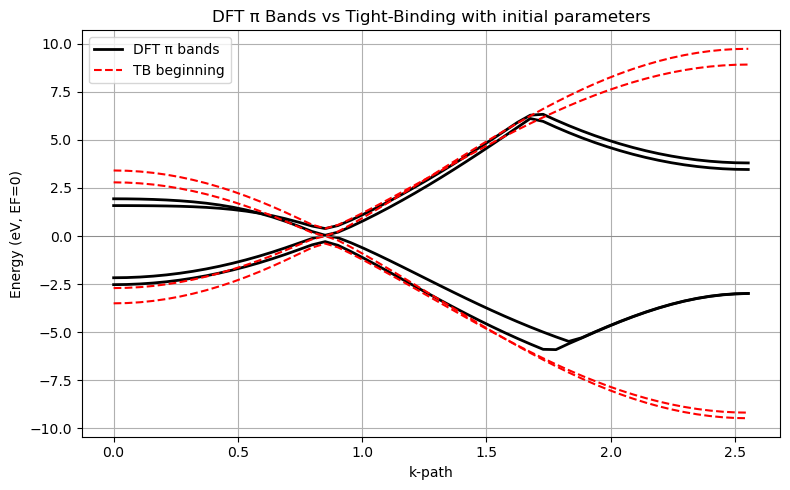

In [31]:
import matplotlib.pyplot as plt

dk = np.sqrt(np.sum(np.diff(kpts, axis=0)**2, axis=1))
x = np.concatenate([[0], np.cumsum(dk)])
E_tb_0 = manager.tb_bands(kpts, theta0)

plt.figure(figsize=(8,5))

nb = E_pi.shape[1]

# DFT π bands
for i in range(nb):
    plt.plot(x, E_pi[:, i], 'k-', lw=2, label="DFT π bands" if i==0 else "")

# TB π bands
for i in range(4):
    plt.plot(x, E_tb_0[:, i], 'r--', lw=1.5, label="TB beginning" if i==0 else "")

plt.axhline(0, color='gray', lw=0.5)
plt.xlabel("k-path")
plt.ylabel("Energy (eV, EF=0)")
plt.title("DFT π Bands vs Tight-Binding with initial parameters")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
from tb_parameters_optimizer import optimize
E_pi_ordered = E_pi[:, [2, 0, 1, 3]] # IMPORTANT! Must reorder bands so that they match from the two models.

theta_fit = optimize(manager, theta0, kpts, E_pi_ordered, 0.5, 1.5)


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.2031e+00                                    1.44e+01    
       1              3         1.0135e+00      3.19e+00       7.85e-01       2.31e+00    
       2              4         6.4089e-01      3.73e-01       3.81e-01       5.62e-01    
       3              5         6.3817e-01      2.72e-03       1.91e-01       4.89e-01    
       4              6         6.1831e-01      1.99e-02       4.79e-02       1.79e-01    
       5              7         6.1120e-01      7.11e-03       9.57e-02       7.07e-02    
       6              9         6.1041e-01      7.91e-04       1.51e-02       1.40e-02    
       7             11         6.1034e-01      7.56e-05       5.65e-03       4.02e-03    
       8             13         6.1032e-01      1.11e-05       2.02e-03       2.07e-03    
       9             14         6.1032e-01      1.20e-06       3.65e-03       3.08e-03    

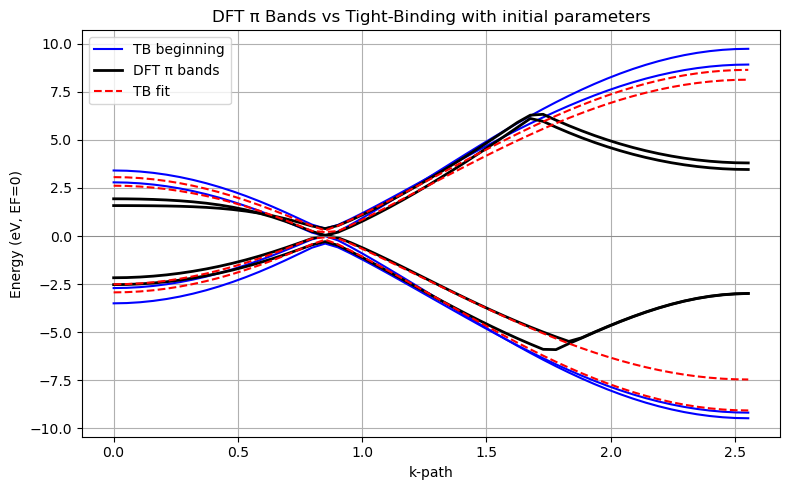

In [33]:
import matplotlib.pyplot as plt
import numpy as np

dk = np.sqrt(np.sum(np.diff(kpts, axis=0)**2, axis=1))
x = np.concatenate([[0], np.cumsum(dk)])
E_tb_0 = manager.tb_bands(kpts, theta0)
E_tb_fit = manager.tb_bands(kpts, theta_fit)


plt.figure(figsize=(8,5))

nb = E_pi.shape[1]

for i in range(nb):
    plt.plot(x, E_tb_0[:, i], 'b-', lw=1.5, label="TB beginning" if i==0 else "")

# DFT π bands
for i in range(nb):
    plt.plot(x, E_pi[:, i], 'k-', lw=2, label="DFT π bands" if i==0 else "")

# TB π bands
for i in range(4):
    plt.plot(x, E_tb_fit[:, i], 'r--', lw=1.5, label="TB fit" if i==0 else "")

plt.axhline(0, color='gray', lw=0.5)
plt.xlabel("k-path")
plt.ylabel("Energy (eV, EF=0)")
plt.title("DFT π Bands vs Tight-Binding with initial parameters")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Zoom in
Now we want to zoom in to see the result. We need to rer

In [71]:
from ase.dft.kpoints import get_bandpath
path = ['M', 'K', 'G']
bp = get_bandpath(path, atoms.cell)

k_point = bp.special_points['K']
k_point

array([ 0.33333333, -0.33333333,  0.        ])

In [59]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
%reload_ext autoreload

In [61]:
from extract_pi_dft_bands import save_pi_dft_bands
save_pi_dft_bands(atoms, calc, path=['M', 'K', 'G'], npoints=200, zoom_label='K', zoom_distance=0.5)

Going to get distance 0.5 around K
Current kpath [[ 0.38131313 -0.23737374  0.        ]
 [ 0.37878788 -0.24242424  0.        ]
 [ 0.37626263 -0.24747475  0.        ]
 [ 0.37373737 -0.25252525  0.        ]
 [ 0.37121212 -0.25757576  0.        ]
 [ 0.36868687 -0.26262626  0.        ]
 [ 0.36616162 -0.26767677  0.        ]
 [ 0.36363636 -0.27272727  0.        ]
 [ 0.36111111 -0.27777778  0.        ]
 [ 0.35858586 -0.28282828  0.        ]
 [ 0.35606061 -0.28787879  0.        ]
 [ 0.35353535 -0.29292929  0.        ]
 [ 0.3510101  -0.2979798   0.        ]
 [ 0.34848485 -0.3030303   0.        ]
 [ 0.3459596  -0.30808081  0.        ]
 [ 0.34343434 -0.31313131  0.        ]
 [ 0.34090909 -0.31818182  0.        ]
 [ 0.33838384 -0.32323232  0.        ]
 [ 0.33585859 -0.32828283  0.        ]
 [ 0.33333333 -0.33333333  0.        ]
 [ 0.33082707 -0.33082707  0.        ]
 [ 0.3283208  -0.3283208   0.        ]
 [ 0.32581454 -0.32581454  0.        ]
 [ 0.32330827 -0.32330827  0.        ]
 [ 0.32080201 -

In [7]:
kpts_zoom, band_energies_zoom, band_indices_zoom, EF_zoom = load_pi_dft_bands()

dk = np.sqrt(np.sum(np.diff(kpts_zoom, axis=0)**2, axis=1))
x = np.concatenate([[0], np.cumsum(dk)])

plt.figure(figsize=(8,5))

nb = band_energies_zoom.shape[1]

# DFT π bands
for i in range(nb):
    plt.plot(x, band_energies_zoom[:, i], 'k-', lw=2, label="DFT π bands" if i==0 else "")

# TB π bands

plt.axhline(0, color='gray', lw=0.5)
plt.xlabel("k-path")
plt.ylabel("Energy (eV, EF=0)")
plt.title("DFT π Bands zoomed on K - Parabolic")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'np' is not defined

Notice the parabolic curve, which is correct.

## DFT DOS


In [22]:
import matplotlib.pyplot as plt
import numpy as np

In [11]:
e, dos = calc.get_dos(spin=0, npts=2001, width=0.2)

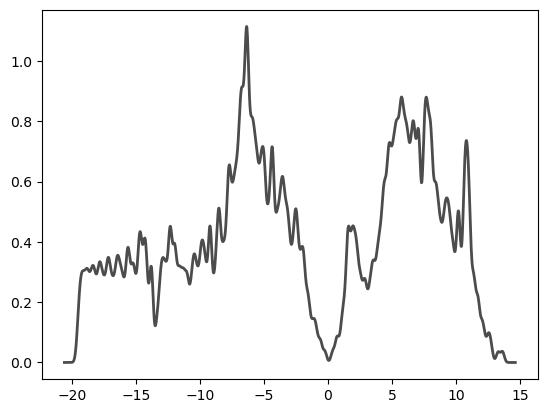

In [12]:
plt.plot(e - EF, dos, label='Total', c='k', lw=2, alpha=0.7)

In [31]:
dist = abs(E_pi.mean(axis=0) - EF)
idx_pi = np.argsort(dist)[:4]   # 4 π bands in bilayer
print("π-band indices:", idx_pi)


π-band indices: [3 0 1 2]


In [64]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [68]:
import importlib
import pdos_plotter

importlib.reload(pdos_plotter)   # reloads the module
from pdos_plotter import plot_pdos_pi_sigma   #

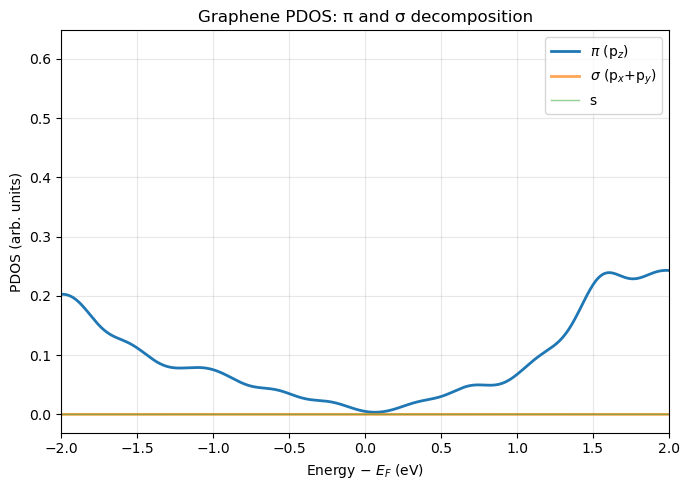

Saved interactive PDOS to: ../data/graphene_pdos_interactive.html


In [69]:
from pdos_plotter import plot_pdos_pi_sigma

# assuming you already have:
# atoms, calc = restart('yourfile.gpw')
plot_pdos_pi_sigma(calc, atoms, atom_indices=[0,1,2,3,], zoom=(-2, 2), save_html=True)

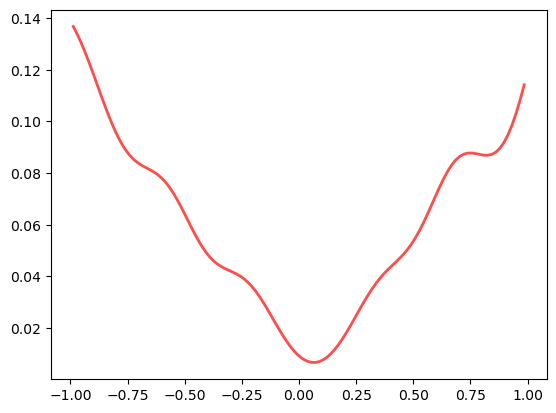

In [14]:
e_min_EF = e - EF
filter = (e_min_EF > -1) & (e_min_EF < 1)
plt.plot(e_min_EF[filter], dos[filter], label='Band', c='r', lw=2, alpha=0.7)

In [17]:
dos[filter].min()

np.float64(0.006618160771627887)